# LASDOT — station pipeline demo

Three modules, each a stage of the same pipeline:

| module | what it does |
|---|---|
| `station_projection.py` | global (E, N, Z) → (station, offset, Z) against a centerline |
| `sort_by_station.py` | rewrites a cloud in station order + writes the even-foot index |
| `cross_section.py` | pulls one station's slice out of a sorted cloud, rotated into a local frame |

## Setup

In [2]:
import os

import laspy as lp
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

from station_projection import PreparedCenterline, load_centerline, prepare_centerline, xyz2sta
from sort_by_station import build_foot_index, sort_las_by_station
from cross_section import (
    get_candidate_points,
    rotate_to_section_frame,
    select_section_window,
    write_cross_section,
)

# The small tile -- fast enough to sort live further down.
TILE_LAS = 'data/015R_I_19.194_19.388 1.las'
TILE_CL = 'data/015R_I_19.194_19.388 1_CL.txt'

# The big one, already sorted in Part 2.
GOLD_SORTED = 'data/Gold1Test_SORTED.las'
GOLD_INDEX = 'data/Gold1Test_SORTED.csv'
GOLD_CL = 'data/Gold1TestCL.txt'

---
# Part 1 — `station_projection.py`

Pure numpy in, pure numpy out. No file handling anywhere in the module: it
takes arrays and returns arrays, so a caller can hand it one chunk at a time.

### The centerline

`load_centerline` reads a plain vertex list (comma, space or tab separated;
extra columns ignored). `prepare_centerline` turns it into a
`PreparedCenterline` — segment starts, unit directions, lengths, the station at
each segment start, and a KD-tree over densified samples. Build it **once** and
reuse it; building the index is the expensive part.

In [3]:
vertices = load_centerline(GOLD_CL)
centerline = prepare_centerline(vertices, sample_spacing=1.0)

---
# Part 2 — `sort_by_station.py`

Rewrites the cloud in station order and writes the even-foot index beside it.
The station values and the corridor cull are computed **once** and feed both
outputs, so the CSV's row numbers cannot drift out of step with the LAS.

### A live sort on the small tile

6.4M points, a few seconds. `road_width` is the corridor: anything further than
half of it from the centerline is dropped.

In [4]:
demo_sorted = 'data/demo_SORTED.las'
demo_index = 'data/demo_SORTED.csv'

counts = sort_las_by_station(
    TILE_LAS,
    TILE_CL,
    road_width=60.0,
    out_las=demo_sorted,
    out_csv=demo_index,
)

counts

{'processed': 6412449,
 'kept': 6309095,
 'dropped_by_cull': 103354,
 'skipped_invalid': 0,
 'index_rows': 314,
 'first_station': 0.0,
 'last_station': 312.47844827748594}

### The same call on a 560M point cloud

**Already run — do not re-execute.** The output below is preserved from the
real run: 560M points in, 23M kept inside a 100 ft corridor.

In [5]:
las_infile = '/home/nurveyor/Documents/211110_GoldCoast_p1_120_85_85_guided_v3.las'
cl_infile = 'data/Gold1TestCL.txt'

las_outfile = 'data/Gold1Test_SORTED.las'
tab_outfile = 'data/Gold1Test_SORTED.csv'

if not os.path.exists(las_outfile):
    sort_las_by_station(las_infile, cl_infile, 100, las_outfile, tab_outfile)

### What it all bought: a station window as one contiguous read

Two lookups in a 2,666-row table, one `seek`, one `read_points`. The 23M point
file is never scanned.

In [6]:
table = np.loadtxt(GOLD_INDEX, delimiter=',', skiprows=1, ndmin=2)  # the even-foot index, one row per foot: "station_ft,start_index"
feet = table[:, 0]                         # column 0 -- the foot mark each row describes
starts = table[:, 1].astype(np.int64)      # column 1 -- the point row where that foot begins
sentinel = len(starts) - 1                 # the last row is the sentinel (one past the end), not a real foot

low = 1201.5                               # the station window we want, in feet -- may be fractional
high = 1210.8

i_low = int(np.searchsorted(feet, np.floor(low)))          # table row for the foot that CONTAINS low
i_high = int(np.searchsorted(feet, np.floor(high) + 1.0))  # table row for the foot just AFTER the one containing high

start = int(starts[min(i_low, sentinel)])  # -> first point row to read; the clamp guards a station past the end of the table
stop = int(starts[min(i_high, sentinel)])  # -> one past the last point row to read

with lp.open(GOLD_SORTED) as reader:       # opens the header only -- the 23M points stay on disk
    gold_total = reader.header.point_count # the file's point count, used by the report below and in Part 3
    reader.seek(start)                     # jump straight to row `start`; nothing before it is read
    window = reader.read_points(stop - start)  # ONE contiguous read of the whole span

In [7]:
window_station = np.asarray(window.station)                  # the station of every point we read
inside = (window_station >= low) & (window_station <= high)  # the index cuts on whole feet, so trim to the exact bounds

print(f'window {low} .. {high} ft')                                                             # what was asked for
print(f'  rows {start:,} .. {stop:,}  ({stop - start:,} points read)')                           # the two lookups, as point rows
print(f'  {100 * (stop - start) / gold_total:.3f}% of the file touched')                         # how little of the 23M was read
print(f'  read span  {window_station.min():.3f} .. {window_station.max():.3f}')                  # foot-aligned, so a little wider than asked
print(f'  {int(inside.sum()):,} points inside the exact bounds')                                 # what survives the fractional trim
print(f'  exact span {window_station[inside].min():.3f} .. {window_station[inside].max():.3f}')  # now inside low .. high
print(f'  already in order: {bool(np.all(np.diff(window_station) >= 0))}')                       # the sort invariant -- no re-sorting needed

window 1201.5 .. 1210.8 ft
  rows 9,285,382 .. 9,351,402  (66,020 points read)
  0.284% of the file touched
  read span  1201.000 .. 1211.000
  60,771 points inside the exact bounds
  exact span 1201.500 .. 1210.800
  already in order: True


---
# Part 3 — `cross_section.py`

Four functions. The first three are the steps; the fourth is the one to call.

The output frame is right-handed with its origin on the centerline at the
requested station:

```
+y  along the centerline, in the direction of travel
+x  square to it, increasing to the RIGHT of travel
+z  elevation, exactly as it was -- never touched
```

### 1. `get_candidate_points` — the indexed read

Deliberately gathers **more** than the section needs. Station is arc length
along a bending centerline, but the section frame is flat, so near a bend a
point's station and its position along the section's y axis are different
numbers. Gather generously, clip later in the rotated frame.

In [8]:
STATION = 1200.0
HALF_LENGTH = 25.0

candidates, source_header = get_candidate_points(
    GOLD_SORTED, GOLD_INDEX, STATION, HALF_LENGTH
)

candidate_station = np.asarray(candidates.station)
print(f'read {len(candidates):,} candidates of {gold_total:,} in the file')
print(f'  = {100 * len(candidates) / gold_total:.2f}%, in ONE seek + ONE read')
print(f'  stations {candidate_station.min():.2f} .. {candidate_station.max():.2f}')
print(f'  every field intact: {len(candidates.array.dtype.names)} dimensions')

read 390,768 candidates of 23,209,145 in the file
  = 1.68%, in ONE seek + ONE read
  stations 1175.00 .. 1226.00
  every field intact: 16 dimensions


### 2. `rotate_to_section_frame` — shift, then rotate

The shift puts the centerline point at this station on the origin; elevation is
left alone. The rotation turns the cloud about the vertical axis until travel
points along +y.

Only kappa is needed — the section frame stays level, so the new x and y axes
stay in the old xy plane. This follows `PointCloudSectioning.ipynb`:
`kappa = -arctan2(v[0], v[1])`.

In [9]:
survey_xyz = np.column_stack([
    np.asarray(candidates.x),
    np.asarray(candidates.y),
    np.asarray(candidates.z),
])

gold_centerline = prepare_centerline(load_centerline(GOLD_CL))
rotated, origin, kappa = rotate_to_section_frame(survey_xyz, gold_centerline, STATION)

print(f'origin on the centerline : ({origin[0]:.3f}, {origin[1]:.3f})')
print(f'kappa                    : {kappa:.6f} rad = {np.degrees(kappa):.4f} deg')
print()
print(f'{"":>10} {"before (survey)":>34}   {"after (section)":>26}')
for i in (0, len(rotated) // 2):
    b, a = survey_xyz[i], rotated[i]
    print(f'point {i:>4} {b[0]:12.3f} {b[1]:12.3f} {b[2]:8.2f}   {a[0]:8.3f} {a[1]:8.3f} {a[2]:8.2f}')

origin on the centerline : (2168097.048, 665356.450)
kappa                    : 1.181858 rad = 67.7155 deg

                              before (survey)              after (section)
point    0  2168111.988   665326.980   639.81    -21.603  -25.000   639.81
point 195384  2168117.725   665398.657   659.97     46.896   -3.128   659.97


### 3. `select_section_window` — the clip

Returns a boolean **mask**, not points, so the caller can apply it to the whole
laspy record and carry every field through.

In [10]:
LEFT, RIGHT, THICKNESS = 25.0, 25.0, 1.0

mask = select_section_window(rotated, LEFT, RIGHT, THICKNESS)

print(f'{len(mask):,} candidates -> {int(mask.sum()):,} inside the window')
print(f'  x kept within  -{LEFT} .. {RIGHT}')
print(f'  y kept within  +/- {THICKNESS / 2}')
print()
kept = rotated[mask]
print(f'actual x range: {kept[:, 0].min():7.3f} .. {kept[:, 0].max():7.3f}')
print(f'actual y range: {kept[:, 1].min():7.3f} .. {kept[:, 1].max():7.3f}')
print(f'actual z range: {kept[:, 2].min():7.2f} .. {kept[:, 2].max():7.2f}  (real elevation)')

390,768 candidates -> 3,433 inside the window
  x kept within  -25.0 .. 25.0
  y kept within  +/- 0.5

actual x range: -24.999 ..  24.997
actual y range:  -0.500 ..   0.500
actual z range:  639.03 ..  680.81  (real elevation)


### 4. `write_cross_section` — the wrapper

The one to actually call. `left_offset` defaults to `right_offset`;
`half_length` defaults to half the section's width. Writes the section LAS and
its transform `.txt`, both named for the station.

In [11]:
section = write_cross_section(
    GOLD_SORTED,
    GOLD_INDEX,
    GOLD_CL,
    station=1200.0,
    right_offset=25.0,
    thickness=1.0,
)

for name, value in section.items():
    print(f'{name:16s} {value}')

las_path         data/Gold1Test_SORTED_sta001200_00.las
txt_path         data/Gold1Test_SORTED_sta001200_00.txt
origin           (2168097.0475936797, 665356.4500499943)
kappa            1.181857951410319
candidates_read  390768
points_kept      3433


Station 1200.00 becomes the suffix `sta001200_00` — six digits of whole feet,
then the hundredths after an underscore.

In [12]:
print(open(section['txt_path']).read())

# Cross-section transform parameters
# Written by cross_section.py

source_las      = data/Gold1Test_SORTED.las
source_index    = data/Gold1Test_SORTED.csv
centerline      = data/Gold1TestCL.txt
source_crs_vlr  = LASF_Projection 34735, LASF_Projection 34736, LASF_Projection 34737 (stripped from this section)
station         = 1200.0000
left_offset     = 25.0000
right_offset    = 25.0000
thickness       = 1.0000
origin_easting  = 2168097.0476
origin_northing = 665356.4500
kappa_rad       = 1.181857951410
kappa_deg       = 67.715473
cos_kappa       = 0.379206294838
sin_kappa       = 0.925312155954
point_count     = 3433

# Section (x, y, z) back to survey (E, N, Z):
#     E = origin_easting  + x*cos_kappa - y*sin_kappa
#     N = origin_northing + x*sin_kappa + y*cos_kappa
#     Z = z          (elevation was never altered)
#
# The section frame is right-handed: +x is right of travel,
# +y is the direction of travel, +z is up.



### Looking at it

The section drawn at **true 1:1** — x across the page (left of road to right),
z up the page, one foot the same length on both axes. That is the whole point of
a rigid frame: the picture can be measured off.

Points are shaded by intensity, which is the one thing the geometry does not
already show. Pass `exaggeration` to stretch the vertical when a cross-slope is
too subtle to see at 1:1.

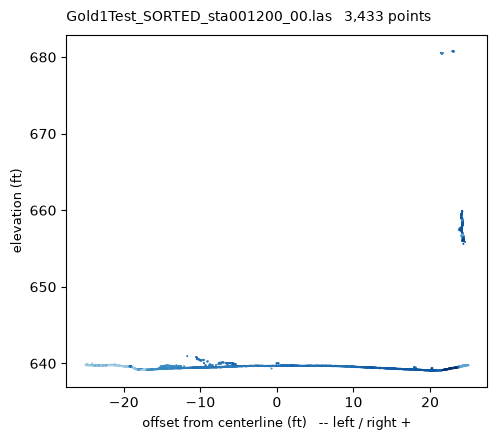

In [18]:
def plot_section(section_las, exaggeration=1.0, point_size=2.0):
    '''Draw a cross-section: offset across, elevation up, true 1:1 by default.'''
    cloud = lp.read(section_las)
    x = np.asarray(cloud.x)
    z = np.asarray(cloud.z)
    intensity = np.asarray(cloud.intensity).astype(float)

    fig, ax = plt.subplots(figsize=(11, 4.5))

    # Magnitude -> one hue, light to dark. The palest third of Blues is dropped
    # so weak returns stay visible against a white surface.
    ramp = mcolors.ListedColormap(plt.get_cmap('Blues')(np.linspace(0.35, 1.0, 256)))

    # Clip the ends of the intensity range: a handful of hot returns would
    # otherwise flatten every real difference in the pavement.
    ax.scatter(
        x, z,
        c=intensity, cmap=ramp,
        vmin=np.percentile(intensity, 2), vmax=np.percentile(intensity, 98),
        s=point_size, linewidths=0,
    )

    # 1.0 == one foot of elevation drawn as long as one foot of offset.
    ax.set_aspect(exaggeration)

    ax.set_xlabel('offset from centerline (ft)   -- left / right +', fontsize=9)
    ax.set_ylabel('elevation (ft)', fontsize=9)
    ax.set_title(
        f'{os.path.basename(section_las)}   {len(x):,} points'
        + ('' if exaggeration == 1.0 else f'   vertical x{exaggeration:g}'),
        fontsize=10, loc='left', pad=10,
    )

    fig.tight_layout()
    plt.show()


plot_section(section['las_path'])

### Cutting a run of sections

The wrapper is cheap to call in a loop: each section is its own indexed read.

In [14]:
for station in [1180.0, 1190.0, 1200.0, 1210.0, 1220.0]:
    cut = write_cross_section(
        GOLD_SORTED, GOLD_INDEX, GOLD_CL,
        station=station,
        right_offset=25.0,
        thickness=1.0,
    )
    name = os.path.basename(cut['las_path'])
    print(f"{name:44s} {cut['points_kept']:6,} points "
          f"from {cut['candidates_read']:8,} candidates")

Gold1Test_SORTED_sta001180_00.las             5,045 points from  411,745 candidates
Gold1Test_SORTED_sta001190_00.las             4,004 points from  405,297 candidates
Gold1Test_SORTED_sta001200_00.las             3,433 points from  390,768 candidates
Gold1Test_SORTED_sta001210_00.las             3,202 points from  356,305 candidates
Gold1Test_SORTED_sta001220_00.las             3,159 points from  335,402 candidates


### Asymmetric windows, and a partial station

`left_offset` and `right_offset` are independent, and the station can be
partial — the section stands exactly where it is asked to.

In [15]:
lopsided = write_cross_section(
    GOLD_SORTED, GOLD_INDEX, GOLD_CL,
    station=1200.25,
    right_offset=30.0,
    left_offset=5.0,
    thickness=2.0,
)

cloud = lp.read(lopsided['las_path'])
x = np.asarray(cloud.x)
print(os.path.basename(lopsided['las_path']))
print(f"  {lopsided['points_kept']:,} points")
print(f'  x range {x.min():.2f} .. {x.max():.2f}   (asked -5 .. +30)')
print(f"  y range {np.asarray(cloud.y).min():.2f} .. {np.asarray(cloud.y).max():.2f}   (asked +/- 1.0)")

Gold1Test_SORTED_sta001200_25.las
  4,766 points
  x range -5.00 .. 30.00   (asked -5 .. +30)
  y range -1.00 .. 1.00   (asked +/- 1.0)


---
## Notes

- **The section LAS is not in the survey CRS.** Its x/y are local feet from the
  station origin, so the projection VLRs are stripped rather than left to claim
  coordinates the file no longer has. The parent CRS is named in the `.txt`
  alongside the numbers to get back.
- **Elevation is never altered**, anywhere in the pipeline. The centerline is a
  2D thing, so there is no z to shift, and reusing the source z scale and offset
  means the stored integers copy through bit-exactly.
- **Candidate bands are generous by design.** At ±25 ft the section above read
  ~390k points to keep ~3.4k. It is one contiguous read, so it is fast; pass
  `half_length` explicitly to tighten it on a stretch you know is straight.
- Sections written here land in `data/`, which is gitignored.